# Chatbot w Multiple Tools

tools:
- arxiv : research paper searching tool
- wikipedia
- custom tool
- tavily: helps llms search the web / internet search

In [7]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

Tavily Tool

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
tavily.invoke("Provide recent AI news for June 2029")

C:\Users\Dell\AppData\Local\Temp\ipykernel_13368\1418459558.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'AI News You Need to Know — June Edition: Capex, Inference, & Beyond',
  'url': 'https://www.etftrends.com/artificial-intelligence-content-hub/ai-news-need-know-june-edition-capex-inference-beyond',
  'content': '## Beyond (Applications — Digital and Physical)\n\nThis is where AI stops being infrastructure and becomes a product in use, across three very different industries last week.\n\nRobinhood (HOOD), the retail brokerage, opened its platform to AI agents. Its Agentic Trading beta lets a bot — built on Anthropic’s Claude or OpenAI’s ChatGPT —  place trades on a user’s behalf inside a separate, walled-off account. Options and crypto are to follow. Handing an AI the keys to a brokerage account, even a sandboxed one, is a threshold for the firm’s 27 million customers. It’s also a sign of how quickly AI that acts on its own is moving from concept to shipped feature. [...] Inference is also moving closer to the user. At the Computex trade show, chipmaker Nvidia (NVDA) and Mic

Arxiv Tool

In [22]:
import arxiv

def search_arxiv(query: str) -> str:
    """Search arxiv for research papers
    Args:
       Query: str
    Returns: str
    """
    client=arxiv.Client()
    search = arxiv.Search(
        query=query,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance
    )
    output=[]
    for paper in client.results(search):
        output.append(
            f"""
Title: {paper.title}
Authors: {', '.join(a.name for a in paper.authors)}
Published: {paper.published.strftime('%Y-%m-%d')}
Summary:
{paper.summary[:500]}
PDF:
{paper.pdf_url}
"""
        )
        return "\n\n".join(output)

In [23]:
result = search_arxiv("Attention is all you need")
print(result)


Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Published: 2021-05-06
Summary:
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a
PDF:
https://arxiv.org/pdf/2105.02723v1



Wikipedia Tool

In [29]:
import wikipediaapi
import wikipedia
wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent = "pappu"
)
def search_wikipedia(query:str) -> str:
    """Seach wikipedia for a query and returns best matching article
    Args:
       Query: str
    Returns: str"""

    try:
        results=wikipedia.search(query)
        if not results:
            return "No matching Wikipedia articles found."
        
        page = wiki.page(results[0])

        return f"""
Title: {page.title}
Summary:
{page.summary[:500]}
URL:
{page.fullurl}
"""
    except Exception as e:
        return str(e)


Tools collection

In [30]:
tools=[tavily,search_arxiv,search_wikipedia]

Initializing the LLM

In [31]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)

Building the entire Chatbot w Langgraph

In [33]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

State Schema

In [34]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph.message import AnyMessage,add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

Main LLM Node

In [35]:
def tool_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

Building the graph

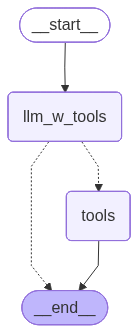

In [36]:
builder = StateGraph(State)

builder.add_node("llm_w_tools",tool_llm)
builder.add_node("tools",ToolNode(tools=tools))

builder.add_edge(START,"llm_w_tools")
builder.add_conditional_edges("llm_w_tools",tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

invoking the llm and its tools

In [ ]:
from pprint import pprint
# arxiv
result = graph.invoke({"messages":"What is attention is all you need"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================
Tool Calls:
  search_arxiv (y2rkxfnzg)
 Call ID: y2rkxfnzg
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: search_arxiv


Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Published: 2021-05-06
Summary:
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied o

In [ ]:
# tavily
result = graph.invoke({"messages":"What is the current temperature in Goa"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is the current temperature in Goa
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (37hm6jvsc)
 Call ID: 37hm6jvsc
  Args:
    query: current temperature in Goa
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Goa Weather Conditions: Temperature | 30 Days Forecast - AQI.in", "url": "https://www.aqi.in/weather/india/goa", "content": "Current Panaji weather condition is Rain Showers with real-time temperature (27°C - Pleasant), humidity 88%, wind 29.5km/h, pressure (1010mb), UV (0),", "score": 0.67140645}, {"title": "Goa Weather in July 2026 - Temperature & Climate - MakeMyTrip", "url": "https://www.makemytrip.com/tripideas/goa/goa-weather-in-july", "content": "The temperature in Goa in July is somewhere around a maximum of 29C during the day and a minim

In [40]:
# wikipedia
result = graph.invoke({"messages":"Tell me something about Steve Jobs"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

Tell me something about Steve Jobs
================================== Ai Message ==================================
Tool Calls:
  search_wikipedia (a9j4v9csa)
 Call ID: a9j4v9csa
  Args:
    query: Steve Jobs
================================= Tool Message =================================
Name: search_wikipedia


Title: Steve Jobs
Summary:
Steven Paul Jobs  (February 24, 1955 – October 5, 2011) was an American businessman, inventor, and investor. A pioneer of the personal computer revolution of the 1970s and 1980s, Jobs co-founded Apple Inc. with his early business partner Steve Wozniak as Apple Computer Company in 1976. After the company's board of directors fired him in 1985, he founded NeXT the same year and purchased Pixar in 1986, becoming its chairman and majority shareholder until 2007. Jobs returned to Apple in 1997 as CEO
URL:
https://en.wikipedia.org/wiki/Steve_Jobs



In [ ]:
# llm only
result = graph.invoke({"messages":"What is machine learning ?"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is machine learning ?
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn patterns and make decisions based on data. Key aspects include:

1. **Learning from Data**: Algorithms improve their performance as they are exposed to more data, identifying patterns or relationships within it.
2. **Types of Learning**:
   - **Supervised Learning**: Uses labeled data to train models (e.g., predicting house prices based on features like size and location).
   - **Unsupervised Learning**: Finds hidden structures in unlabeled data (e.g., clustering customers into groups).
   - **Reinforcement Learning**: Learns by interacting with an environment to maximize rewards (